<a href="https://colab.research.google.com/github/mathdavis26-tech/polygon-splitter/blob/main/Split_in_Half__Vers0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#This file includes various functions needed to split a polygon in half with respect to area.

Note that all polygons are represented as a list of vertices in clockwise or counterclockwise order. If two vertices are next to one another in the list, they have an edge connecting them. Some examples of polygons can be seen in the first coding cell below.

##Functions:
- area
  - uses Shoelace Theorem to find area
  - __Input:__ Vertices of polygon
  - __Returns:__ the area of the polygon

- area_below_c
  - Calculates the area of the polygon below the line defined by $w^Tx=c$
  - __Input:__ Vertices of a polygon, the normal vector $w$ to the direction of cutting, and the displacement $c$ from the origin of the cutting line.
  - __Returns:__ Area of the polygon below the line, the sub-polygon defined below the cut, and the vertices exactly along the cut line.

- find_half
  - Iterates to the find the displacement from the origin that splits the polygon exactly in half with respect to area. Works for both convex and non-convex polygons
  - __Input:__ Vertices of a polygon, the normal vector $w$ to the direction of cutting, an $\epsilon$>0 that determines the degree of accuracy of the line found, and (optional, default 100) the maximum number of iterations
  - __Returns:__ The subshape defined by the polygon below the line, and $c$ (the displacement from the origin of the cutting line)

- point_on_edge_at_c
  - Given a particular edge of the polygon (defined by the vertices at each end), finds the intersection point of the cutting line with the edge
  - __Input:__ vertices of the polygon, direction normal to the direction of cut ($w$), indice of the first vertice in the edge (first based on direction of polygon, i.e. counterclockwise or clockwise), displacement from the origin ($c$)

- exact_half
  - Looks only at the vertices of the polygon before defining a subrange of possible values of $c$ (displacement) and then solving directly for the exact value of $c$ using Quadratic Formula (must exist because of IVT). Works for both convex polygons and non-convex polygons!!
  - __Input:__ vertices of the polygon and the direction normal to the direction of cutting ($w$)
  - __Returns:__ The subshape defined by the polygon below the line, and $c$ (the displacement from the origin of the cutting line)

- ploting
  - Creates a plot of the original polygon, the cutting line, and the area below the cutting line
  - __Input__: the vertices of the polygon, the direction normal to the direction of cutting ($w$), and the displacement from the origin of the cutting line ($c$)
  - __Returns:__ Nothing

- find_half_trace
  - Creates an animation that shows the movement of the cutting line and value of $c$ across iterations of the find_half function
  - __Input__: vertices of the polygon, the direction normal to the direction of cutting ($w$), $\epsilon >0$ which defines the accuracy of the solver, and (optional, default=100) the maximum number of iterations of the solver
  - __Output__: Nothing

  ## Examples can be found at the bottom of this notebook.

In [ ]:
# Example shapes:
import math
square = [(2,1), (2, -3), (-2,-3), (-2,1)] # Area = 16

circle = [(1,0), (math.sqrt(3)/2, -1/2),(math.sqrt(2)/2, -math.sqrt(2)/2), (1/2, -math.sqrt(3)/2),
          (0,-1), (-1/2, -math.sqrt(3)/2), (-math.sqrt(2)/2, -math.sqrt(2)/2), (-math.sqrt(3)/2, -1/2), (-1,0),
          (-math.sqrt(3)/2, 1/2), (-math.sqrt(2)/2, math.sqrt(2)/2), (-1/2, math.sqrt(3)/2), (0,1), (1/2, math.sqrt(3)/2),
          (math.sqrt(2)/2, math.sqrt(2)/2), (math.sqrt(3)/2, 1/2)] # Area ~= pi

triangle = [(0,0), (2,0), (0,1)] # Area = 1

polygon = [(1,3), (2,2), (2,0), (0,0), (0,1)] # Area = 4.5

non_convex = [(0,0), (2,1), (1,0), (4,-2), (0,-2)] # Area=5.5

non_convex_2 = [(-1,3), (0,4),(0,0), (-1,1), (-0.2, 2)] # Area=2.2

In [ ]:
# Calulate Area given vectices/edges
# using shoelace theorem
def area(shape):
    total=0

    n = len(shape)
    for i in range(n):
        x1, y1 = shape[i]
        x2,y2 = shape[(i+1)%n] # modulo means that entry n+1 = entry 1

        total += x1*y2-y1*x2
    return abs(total)/2

In [ ]:
# This function finds the area under a line when given a direction w (as a vector (x,y)')
# and a c (displacement from the origin). The line is defined w^Tx=c

import numpy as np
def area_below_c(shape, w, c):
    # truth values to determine information about previous values
    flag = False # true when the first vertex is <= c
    prev = True # true when the previous vertex is <=c
    on_boundary=True # true when the previous vertex is ==c. Starts out as true for the case that the first vertex seen is >c
    first_bound = False # true when the first item is on the boundary
    # store the vertices defining the area below the line
    subshape = []
    key_points=[]
    # iterate over vertices of the shape
    for i in range(len(shape)):
        boundary = w[0]*shape[i][0]+w[1]*shape[i][1] # w^Tx
        edge = (i-1)%len(shape)

        # if below the line
        if boundary < c:
            # if the previous vertex seen was not below the line, the line intersected between the two vertices. Add this point to the shape
            if not prev:
                c0 = w[0]*shape[i-1][0]+w[1]*shape[i-1][1]
                change_c = w[0]*(shape[i][0]-shape[i-1][0])+w[1]*(shape[i][1]-shape[i-1][1])
                x = shape[i-1][0]+((c-c0)/change_c)*(shape[i][0]-shape[i-1][0])
                y = shape[i-1][1]+((c-c0)/change_c)*(shape[i][1]-shape[i-1][1])
                subshape.append((x,y))
                key_points.append((edge,(x,y)))
            # add the current vertex/corner to shape
            subshape.append(shape[i])
            # adjust truth values
            prev = True
            on_boundary=False
            if i == 0:
                flag = True
            # look for an intersection between vertices if the first vertex was not under and the last one is
            if i == len(shape)-1 and not flag:
                c0 = boundary
                change_c = w[0]*(shape[0][0]-shape[i][0])+w[1]*(shape[0][1]-shape[i][1])
                x = shape[i][0]+((c-c0)/change_c)*(shape[0][0]-shape[i][0])
                y = shape[i][1]+((c-c0)/change_c)*(shape[0][1]-shape[i][1])
                subshape.append((x,y))
                key_points.append((i,(x,y)))

        # exact intersection is simply adding vertex to shape
        if boundary == c:
            subshape.append(shape[i])
            key_points.append((edge,shape[i]))
            on_boundary = True
            prev=True
            if i == 0:
                flag = True
                first_bound = True

        # if above the line
        if boundary > c:
            # the previous vertex was under the line and was not on the line, must've intersected between lines
            if prev and not on_boundary:
                c0 = w[0]*shape[i-1][0]+w[1]*shape[i-1][1]
                change_c = w[0]*(shape[i][0]-shape[i-1][0])+w[1]*(shape[i][1]-shape[i-1][1])
                x = shape[i-1][0]+((c-c0)/change_c)*(shape[i][0]-shape[i-1][0])
                y = shape[i-1][1]+((c-c0)/change_c)*(shape[i][1]-shape[i-1][1])
                subshape.append((x,y))
                key_points.append((edge,(x,y)))
            # Adjust truth values
            prev = False
            if i== 0:
                flag = False
            on_boundary = False
            # the first vertex was below and the last is above, must intersect between them
            if i == len(shape)-1 and flag and not first_bound:
                c0 = boundary
                change_c = w[0]*(shape[0][0]-shape[i][0])+w[1]*(shape[0][1]-shape[i][1])
                x = shape[i][0]+((c-c0)/change_c)*(shape[0][0]-shape[i][0])
                y = shape[i][1]+((c-c0)/change_c)*(shape[0][1]-shape[i][1])
                subshape.append((x,y))
                key_points.append((i,(x,y)))

    return area(subshape), subshape, key_points

In [ ]:
# finds half with accuracy epsilon
def find_half(shape, w, eps, max_iter=100):
    A = area(shape)
    # Given a direction, the problem simplifies to finding a c that
    # cuts the polygon in half. This c must intersect the polygon, thus it must be between the
    # minimum and maximum c's that intersect the vertices
    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c_min = min(c)
    c_max=(max(c))
    # goal
    want = A/2
    # a good first guess is between the min and max
    c0 = (c_max + c_min)/2
    for _ in range(max_iter):
        # calculate the area below the line given a c0
        a, subshape = area_below_c(shape, w, c0)[0:2]

        if abs(a-want) < eps: # we are close enough to the true solution (within epsilon)
            return subshape, c0
        if a < want: # our area is too little, take a step towards the max
            c_min = c0
            c0 = (c0+c_max)/2
        if a > want: # our area is too large, take a step towards the min, note steps get smaller with each iteration
            c_max=c0
            c0 = (c_min +c0)/2

In [ ]:
# helper function that finds intersection with shape at c for a particular edge
def point_on_edge_at_c(shape, w, edge, c):
    n = len(shape)
    p0 = shape[edge] # the edge is one end(vertex) of the line
    p1 = shape[(edge+1)%n] # other defining vertex

    c0 = w[0]*p0[0] +w[1]*p0[1]
    c1 = w[0]*p1[0] +w[1]*p1[1]
    t = (c-c0)/(c1-c0)

    # calculate intersection point
    x = p0[0] + t*(p1[0]-p0[0])
    y = p0[1] + t*(p1[1]-p0[1])

    return x,y

In [ ]:
# The code below solves directly for the half without using an epsilon for error. It seperates the area
# into two regions. The first is the region going through a vertice with area close to but less than Area/2.
# The second region countains no vertices and the two regions together add up to Area/2. Because of this,
# in the second region, I can explicitly solve for the value of $c$ that solves Area($w^Tx \le c$) = Area/2 .

import numpy as np
import math
# returns area below w^Tx = c, the vertices defining the subshape, and the value of c
# works on convex and non-convex polygons!!
def exact_half(shape, w):
    A = area(shape)

    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c = np.array(c)
    c_sort = np.unique(c) # find c values of vertices of polygon

    # initiate variables to store needed information
    c_range =[]
    want = A/2
    areas=[]

    # iterate over possible c values (in order)
    for i in range(len(c_sort)):
        a, subshape, key_points = area_below_c(shape, w, c_sort[i])
        areas.append(a)
        if a ==want:
            return subshape, c_sort[i] # if the line for half area goes through vertex
        if a > want: # since we start iterating from the negative end of c's, we find the c just above half area here
            c_range.append(c_sort[i-1])
            c_range.append(c_sort[i])
            a_below = areas[i-1]
            break

    c_mid = (c_range[0] + c_range[1])/2 # here, cutting NO vertices
    _, _, mid_keys = area_below_c(shape, w, c_mid)

    edges = sorted(edge for edge, point in mid_keys) # should already be sorted but this is ensures a sorting

    if len(edges)%2==0: # should always be the case because are not cutting any vertices
      x0, y0 = point_on_edge_at_c(shape, w, edges[0], c_range[0])
      u0, v0 = point_on_edge_at_c(shape, w, edges[1], c_range[0])

      x1, y1 = point_on_edge_at_c(shape, w, edges[0], c_range[1])
      u1, v1 = point_on_edge_at_c(shape, w, edges[1], c_range[1])


      c0 = c_range[0]
      # area function above defined to allow both clockwise and counterclockwise orderings of vertices (using absolute value)
      # the calculations below require the area to be signed depending on ordering of vertices
      # in the case that multiple parts are cut off the the main polygon, each subpart
      # should have the same ordering so I only need to check this once
      sub_area = 1/2*(x0*y1-y0*x1 + x1*v1 - y1*u1 + u1*v0 - v1*u0 + u0*y0 - v0*x0)
      if sub_area > 0:
          goal = want - a_below
      else:
          goal = -(want-a_below)
      change_c = c_range[1]-c_range[0]

      # defined points as (x,y)' = (x0, y0)' + t(x1-x0, y1-y0)', where t in [0,1]. To put in terms of c, t = (c-c0)/(c1-c0)
      # then found area using shoelace theorem, simplified to find constants of c^2, c, and 1

      # note that I am subtracting by the goal ONLY in c_const here
      c_const = ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
          +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
          + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c - 2*goal)

      b_const = ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
          - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

      a_const = ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)

      # same as above but for any other cut off parts, if any
      for i in range(int(len(edges)/2)-1):
        x0, y0 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[0])
        u0, v0 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[0])

        x1, y1 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[1])
        u1, v1 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[1])

        # note I do NOT subtract by goal here agin
        c_const += ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
            +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
            + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c)

        b_const += ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
            - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

        a_const += ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)


      # apply quadratic formula
      if a_const != 0:
          c1 = (-b_const + math.sqrt(b_const**2-4*a_const*c_const))/(2*a_const)
          c2 = (-b_const - math.sqrt(b_const**2-4*a_const*c_const))/(2*a_const)

          # when only one solution
          if c1==c2:
              return area_below_c(shape,w, c1)[1],c1

          true1 = c1 > c_range[0] and c1 < c_range[1]
          true2 = c2 > c_range[0] and c2 < c_range[1]

          if true1 and true2:
              raise ValueError('Somethings very wrong') # there should only be one c that satisfies the area constraint
          elif true1:
              return area_below_c(shape, w, c1)[1], c1
          elif true2:
              return area_below_c(shape, w, c2)[1], c2
          else:
              raise ValueError('I give up')
      else:
          c1 = -c_const/b_const # solve the linear function when a_const=0
          return area_below_c(shape, w, c1)[1], c1
    else:
      raise ValueError('Number of Edges not even')

In [ ]:
import matplotlib.pyplot as plt
# plotting code generated by AI
def ploting(shape, w, c):

    shape = np.array(shape, dtype=float)
    w = np.array(w, dtype=float)
    closed = np.vstack([shape, shape[0]])

    fig, ax = plt.subplots()

    # Plot polygon
    ax.plot(closed[:,0], closed[:,1], "k-", linewidth=2)
    ax.fill(shape[:,0], shape[:,1], alpha=0.25)
    ax.scatter(shape[:,0], shape[:,1], color="black", zorder=3)
    plt.title('c={}'.format(c))

    # plot bounds
    xmin, xmax = shape[:,0].min(), shape[:,0].max()
    ymin, ymax = shape[:,1].min(), shape[:,1].max()
    xpad = 0.2* (xmax-xmin if xmax > xmin else 1)
    ypad = 0.2*(ymax-ymin if ymax>ymin else 1)
    xmin -=xpad; xmax +=xpad; ymin -=ypad; ymax+=ypad

    w1, w2=w

    if abs(w2) > 1e-12:
        xs = np.linspace(xmin, xmax, 400)
        ys = (c-w1*xs)/w2
        ax.plot(xs, ys, "r--", linewidth=2)
    elif abs(w1) > 1e-12:
        x = c/w1
        ax.axvline(x, color='red', linestyle='--', linewidth=2)
    else:
        raise ValueError('w is zero vector')
    ax.grid(True)
    plt.show()

In [ ]:
# I let AI make me code to animate the iterations finding the half cut.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def find_half_trace(shape, w, eps, max_iter=100):
    A = area(shape)

    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c_min = min(c)
    c_max=(max(c))
    want = A/2
    trace = []
    c0 = (c_max + c_min)/2

    for _ in range(max_iter):
        a, subshape = area_below_c(shape, w, c0)[0:2]
        trace.append({
            "c" :c0,
            "area": a,
            "subshape": subshape,
            "error": a-want
        })
        if abs(a-want) < eps:
            break
        if a < want:
            c_min = c0
            c0 = (c0+c_max)/2
        if a > want:
            c_max = c0
            c0 = (c_min +c0)/2
    return trace

# animation
def animate_find_half(shape, w, eps=1e-4, interval=900):
    shape_np = np.array(shape, dtype=float)
    w = np.array(w, dtype=float)

    trace = find_half_trace(shape, w, eps)

    fig, ax = plt.subplots(figsize=(7, 6))

    xmin, xmax = shape_np[:, 0].min(), shape_np[:, 0].max()
    ymin, ymax = shape_np[:, 1].min(), shape_np[:, 1].max()

    xpad = 0.25 * (xmax - xmin if xmax > xmin else 1)
    ypad = 0.25 * (ymax - ymin if ymax > ymin else 1)

    xmin -= xpad
    xmax += xpad
    ymin -= ypad
    ymax += ypad

    diag = np.hypot(xmax - xmin, ymax - ymin)

    def line_points(c):
        if np.allclose(w, 0):
            raise ValueError("w cannot be the zero vector")

        # Point on the line w^T x = c
        p0 = (c / np.dot(w, w)) * w

        # Direction vector perpendicular to w
        d = np.array([-w[1], w[0]], dtype=float)
        d = d / np.linalg.norm(d)

        p1 = p0 - diag * d
        p2 = p0 + diag * d
        return p1, p2

    def draw_frame(k):
        ax.clear()

        item = trace[k]
        c = item["c"]
        a = item["area"]
        subshape = item["subshape"]

        closed = np.vstack([shape_np, shape_np[0]])

        # Original polygon stays visually fixed
        ax.plot(closed[:, 0], closed[:, 1], color="black", linewidth=2)
        ax.fill(shape_np[:, 0], shape_np[:, 1], color="lightgray", alpha=0.35)

        # Current below-line subshape
        if len(subshape) >= 3:
            sub_np = np.array(subshape, dtype=float)
            sub_closed = np.vstack([sub_np, sub_np[0]])
            ax.fill(sub_np[:, 0], sub_np[:, 1], color="cornflowerblue", alpha=0.55)
            ax.plot(sub_closed[:, 0], sub_closed[:, 1], color="royalblue", linewidth=2)

        # Current cutting line
        p1, p2 = line_points(c)
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            color="crimson",
            linestyle="--",
            linewidth=2,
            label=rf"$w^T x = {c:.5f}$"
        )

        ax.scatter(shape_np[:, 0], shape_np[:, 1], color="black", zorder=4)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.3)

        ax.set_title(
            f"Iteration {k + 1}/{len(trace)} | "
            f"c = {c:.6f} | "
            f"area = {a:.6f} | "
            f"error = {item['error']:.6f}"
        )

        ax.legend(loc="upper right")

    anim = FuncAnimation(
        fig,
        draw_frame,
        frames=len(trace),
        interval=interval,
        repeat=False
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())

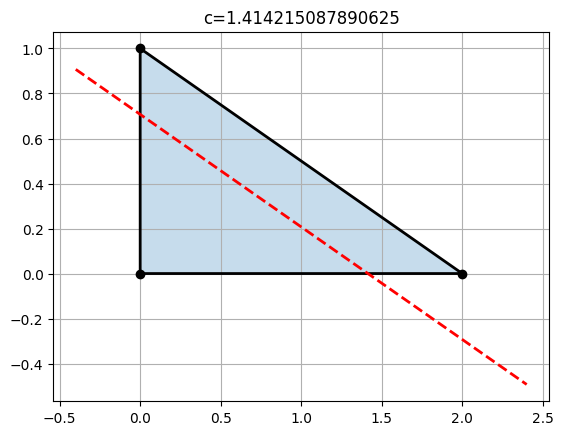

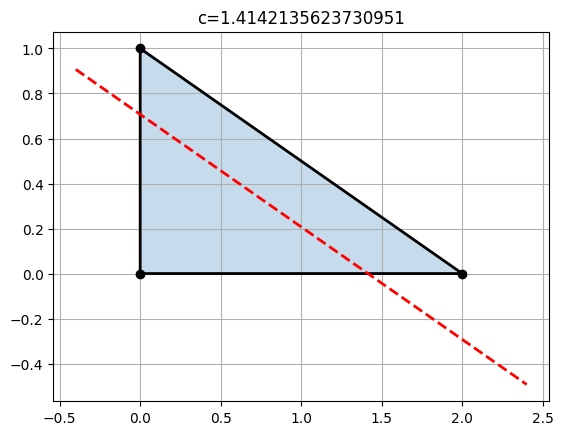

In [ ]:
# plots the iterative solution followed by the exact solution for triangle
ploting(triangle, (1,2), find_half(triangle, (1,2), 10**(-5))[1])
ploting(triangle, (1,2), exact_half(triangle, (1,2))[1])

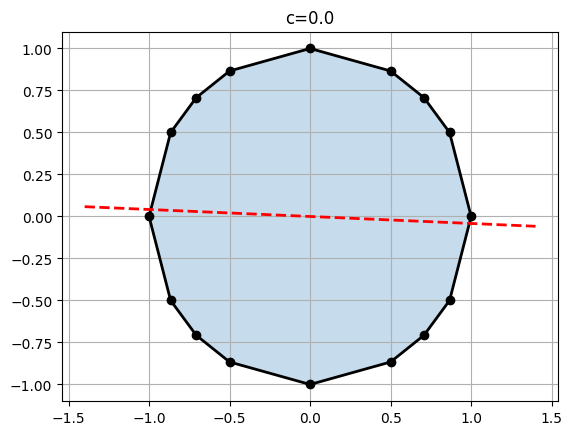

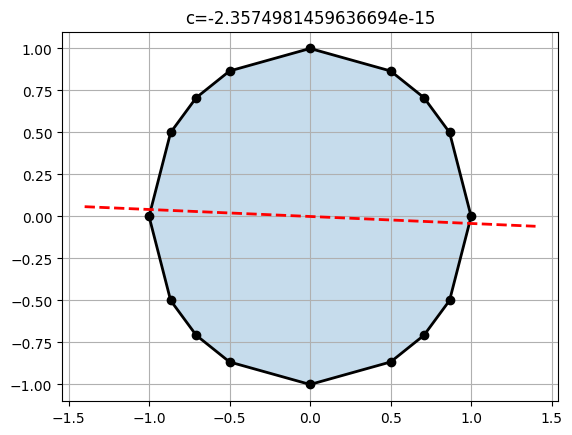

In [ ]:
# plots the iterative solution followed by the exact solution for circle
ploting(circle, (1,24), find_half(circle, (1,24), 10**-5)[1])
ploting(circle, (1,24), exact_half(circle, (1,24))[1])

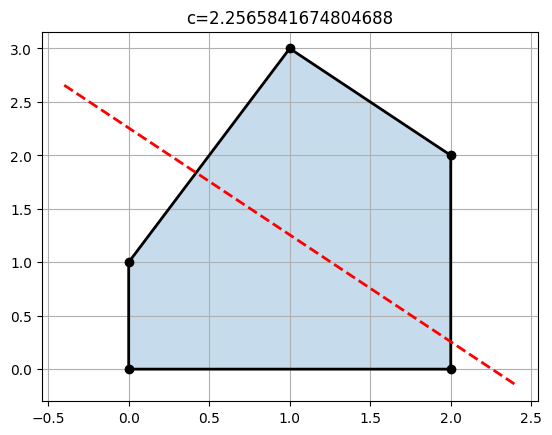

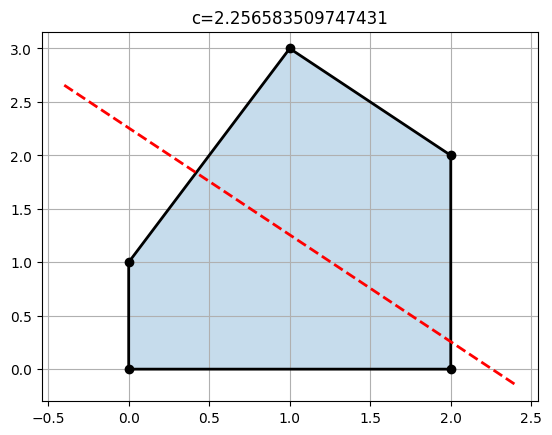

In [ ]:
# plots the iterative solution followed by the exact solution for polygon
ploting(polygon, (1,1), find_half(polygon, (1,1), 10**(-5))[1])
ploting(polygon, (1,1), exact_half(polygon, (1,1))[1])

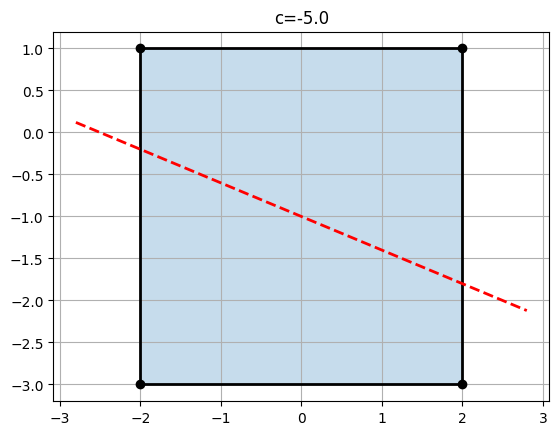

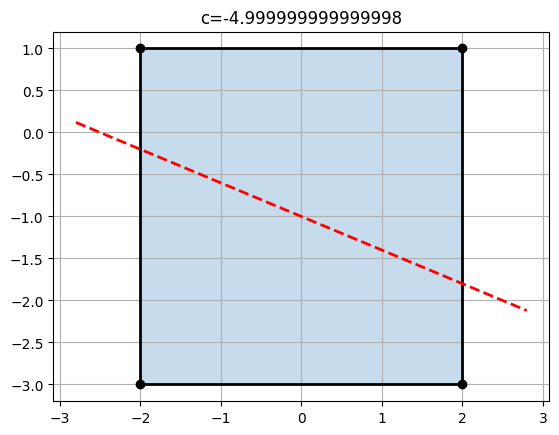

In [ ]:
# plots the iterative solution followed by the exact solution for square
ploting(square, (2,5), find_half(square, (2,5), 10**(-5))[1])
ploting(square, (2,5), exact_half(square, (2,5))[1])

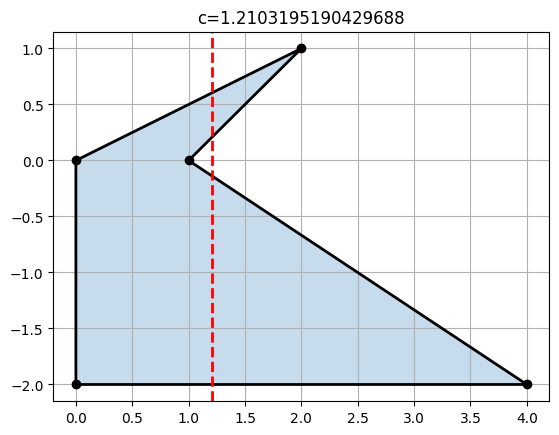

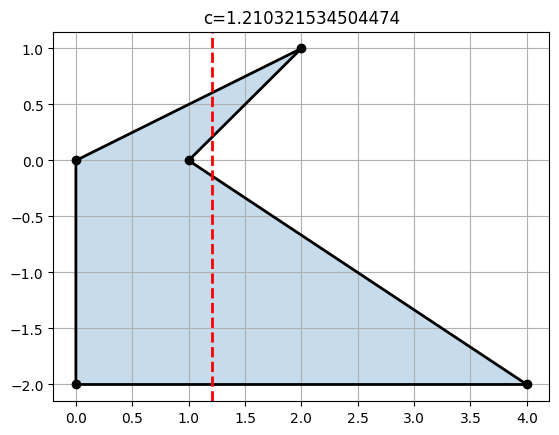

In [ ]:
# plots the iterative solution followed by the exact solution for non_convex
ploting(non_convex, (1,0), find_half(non_convex, (1,0), 10**(-5))[1])
ploting(non_convex, (1,0), exact_half(non_convex, (1,0))[1])

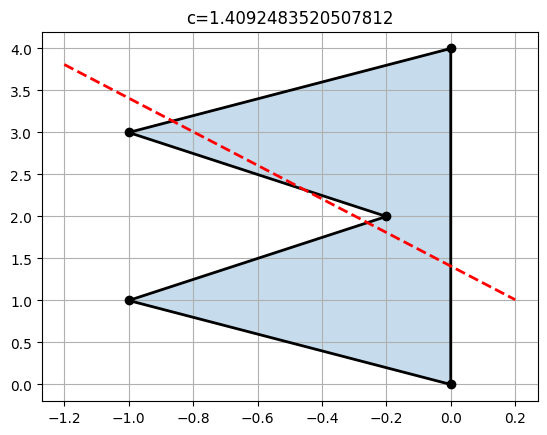

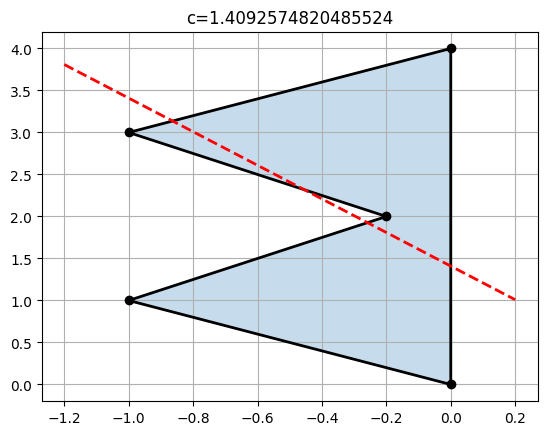

In [ ]:
# plots the iterative solution followed by the exact solution for non_convex_2
ploting(non_convex_2, (2,1), find_half(non_convex_2, (2,1), 10**(-5))[1])
ploting(non_convex_2, (2,1), exact_half(non_convex_2, (2,1))[1])

In [ ]:
# Example animations using triangle and non_convex
animate_find_half(triangle, (3,14), 10**(-10))

In [ ]:
animate_find_half(non_convex, (1,0), 10**(-10))